In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage.color import rgb2gray # Y = 0.2125 R + 0.7154 G + 0.0721 B
import cv2 # RGB[A] to Gray: Y = 0.299 R + 0.587 G + 0.114 B

In [45]:
image = Image.open(r"../../root.jpeg")
root = np.array(image)
root.shape # height, width, colour channels

(3078, 2207, 3)

In [46]:
image.mode

'RGB'

In [6]:
isinstance(image, Image.Image) # cool :)

True

In [47]:
greyscale = rgb2gray(root)
cv_greyscale = cv2.cvtColor(root[:, :, ::-1], # reversing the last dimension to convert RGB to BGR
                        cv2.COLOR_BGR2GRAY)
greyscale.shape, cv_greyscale.shape

((3078, 2207), (3078, 2207))

In [48]:
(root[:, :, ::-1] == root).mean()

np.float64(1.0)

In [43]:
np.arange(start=0, stop=30).reshape(5, 2, 3)

array([[[ 0,  1,  2],
        [ 3,  4,  5]],

       [[ 6,  7,  8],
        [ 9, 10, 11]],

       [[12, 13, 14],
        [15, 16, 17]],

       [[18, 19, 20],
        [21, 22, 23]],

       [[24, 25, 26],
        [27, 28, 29]]])

In [44]:
np.arange(start=0, stop=30).reshape(5, 2, 3)[:, :, ::-1]

array([[[ 2,  1,  0],
        [ 5,  4,  3]],

       [[ 8,  7,  6],
        [11, 10,  9]],

       [[14, 13, 12],
        [17, 16, 15]],

       [[20, 19, 18],
        [23, 22, 21]],

       [[26, 25, 24],
        [29, 28, 27]]])

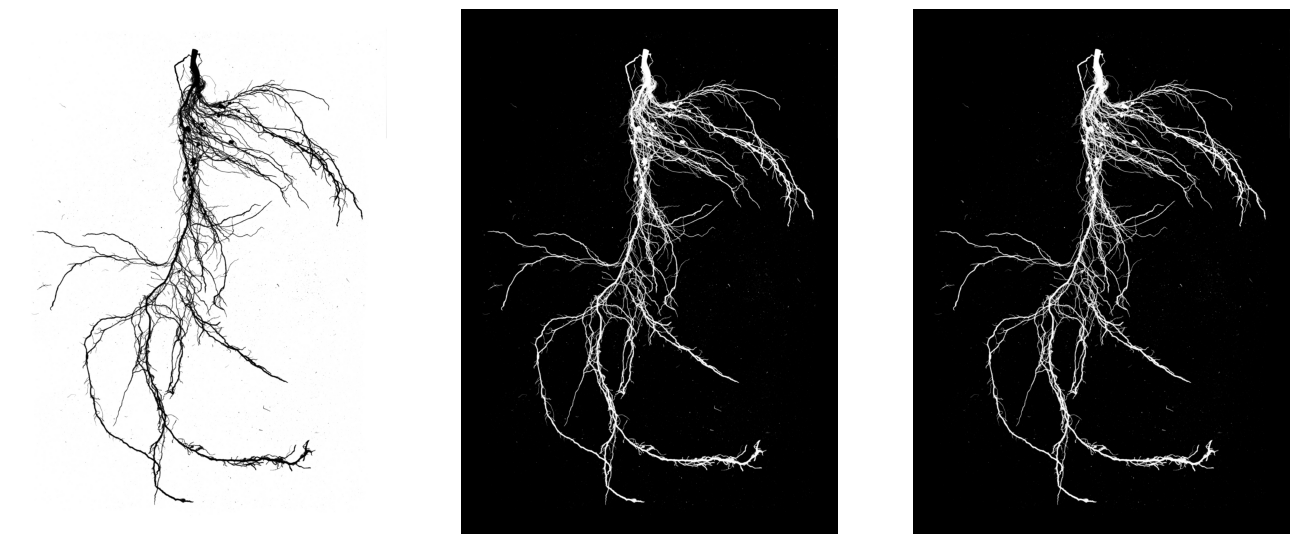

In [30]:
fig, axes = plt.subplots(ncols=3)
fig.set_size_inches(16.5, 7.5)

for ax, im in zip(axes, [root, greyscale, cv_image]):
    ax.imshow(im, cmap="binary")
    ax.set_axis_off()
plt.show()

In [49]:
np.isclose(greyscale, cv_greyscale, atol=0.1, rtol=0.1).mean()

np.float64(0.007012509373418443)

In [51]:
# [B, G, R]
((root * np.array([0.0721, 0.7154, 0.2125], dtype=np.float32)).sum(axis=2) / 255).astype(np.uint8)

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(3078, 2207), dtype=uint8)

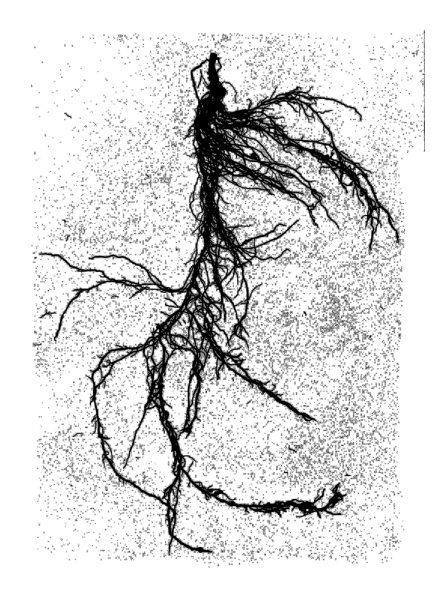

In [53]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 7.5)
axes.imshow(np.bitwise_not(greyscale.astype(np.uint8)), cmap="binary")
axes.set_axis_off()
plt.show()

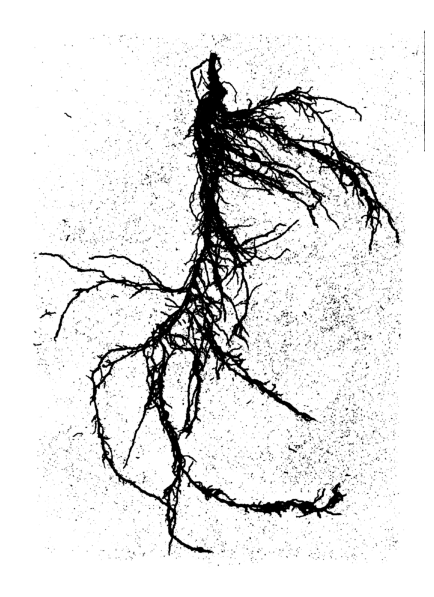

In [62]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 7.5)
axes.imshow(cv2.medianBlur(np.bitwise_not(greyscale.astype(np.uint8)), ksize=5), cmap="binary")
axes.set_axis_off()
plt.show()

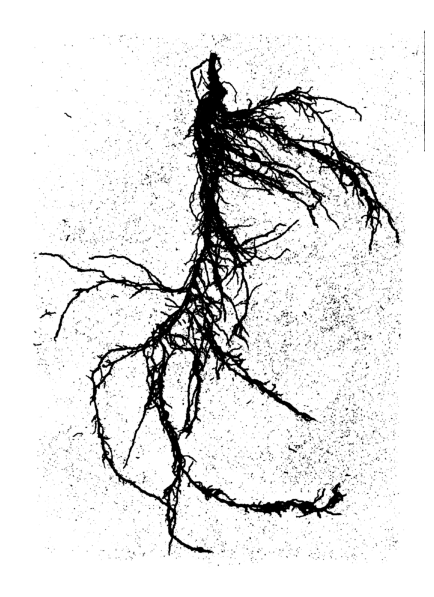

In [65]:
_, thresholded = cv2.threshold(cv2.medianBlur(np.bitwise_not(greyscale.astype(np.uint8)), ksize=5), thresh=0, maxval=255, type=cv2.THRESH_BINARY + cv2.THRESH_OTSU)
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 7.5)
axes.imshow(thresholded, cmap="binary")
axes.set_axis_off()
plt.show()

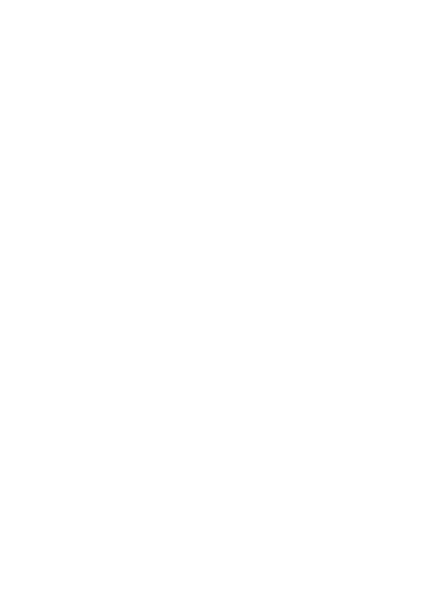

In [69]:
_, thresholded = cv2.threshold(cv2.medianBlur(np.bitwise_not(greyscale.astype(np.uint8)), ksize=5), thresh=0, maxval=255, type=cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 7.5)
axes.imshow(thresholded, cmap="binary")
axes.set_axis_off()
plt.show()

In [71]:
cv_greyscale

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(3078, 2207), dtype=uint8)

In [72]:
np.unique(cv_greyscale)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [ ]:
cv2.bitwise_not()